
# Machine Learning I Final Project

Created by: Michael Doughty


# Dataset Description: Medical (Classification)

## Target
- **target**: Predict whether a patient will be readmitted (1) or not (0).

## Features
- **age**: Patient age in years (min=18, max=90)
- **sex**: Biological sex
- **bmi**: Body Mass Index (min=15, max=55)
- **number_of_prior_admissions**: Number of prior hospital admissions (min=0, max=20)
- **chronic_conditions_count**: Number of chronic conditions (min=0, max=10)
- **admission_type**: Type of hospital admission
- **severity_score**: Overall severity of patient condition (min=0, max=100)
- **lab_result_severity**: Severity indicated by lab results (min=0, max=100)
- **vitals_instability_score**: Instability of vital signs (min=0, max=100)
- **treatment_complexity**: Complexity of treatment required (min=0, max=100)
- **hospital_load_index**: Current hospital capacity utilization (min=0, max=1)
- **physician_workload**: Relative workload of physicians (min=0, max=1)

## Your objectives:
- Train at least 3 classification models
- Evaluate using accuracy, precision, recall, and F1-score
- Compare model performance
- Identify important features


## Project Instructions

1. Load the dataset
2. Perform exploratory data analysis
3. Clean and preprocess the data
4. Train machine learning models
5. Evaluate models

In [35]:
# Basic imports
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Imputer
from sklearn.impute import SimpleImputer
# Pipelines
from sklearn.pipeline import Pipeline
# Train/test split
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
# Scalers
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, precision_recall_curve, roc_curve, auc, precision_score, recall_score, roc_auc_score, confusion_matrix


## Load Dataset

In [36]:
# Load the dataset.
df_medical = pd.read_csv("../datasets/MichaelDoughty_088271_dataset.csv")

### Basic Dataset Information

In [37]:
#Retrieve basic information about the dataset.
df_medical.info()
df_medical.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         978 non-null    float64
 1   sex                         973 non-null    object 
 2   bmi                         966 non-null    float64
 3   number_of_prior_admissions  968 non-null    float64
 4   chronic_conditions_count    961 non-null    float64
 5   admission_type              967 non-null    object 
 6   severity_score              967 non-null    float64
 7   lab_result_severity         971 non-null    float64
 8   vitals_instability_score    968 non-null    float64
 9   treatment_complexity        959 non-null    float64
 10  hospital_load_index         964 non-null    float64
 11  physician_workload          981 non-null    float64
 12  target                      1020 non-null   float64
dtypes: float64(11), object(2)
memory 

,age,bmi,number_of_prior_admissions,chronic_conditions_count,severity_score,lab_result_severity,vitals_instability_score,treatment_complexity,hospital_load_index,physician_workload,target
count,978.000000,966.000000,968.000000,961.000000,967.000000,971.000000,968.000000,959.000000,964.000000,981.000000,1020.000000
mean,53.739264,27.461594,1.991736,1.587929,46.040021,50.927703,40.632128,39.917101,0.492386,0.610061,0.500980
std,21.371896,5.906840,1.449578,1.366573,20.841838,20.419689,23.219265,23.058800,0.202880,0.203988,0.500244
min,18.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.060000,0.000000
25%,35.000000,23.700000,1.000000,1.000000,31.050000,36.800000,24.400000,22.550000,0.350000,0.460000,0.000000
50%,54.000000,27.000000,2.000000,1.000000,45.800000,49.800000,40.450000,37.700000,0.480000,0.620000,1.000000
75%,72.000000,30.700000,3.000000,2.000000,59.400000,64.950000,55.200000,55.450000,0.620000,0.750000,1.000000
max,90.000000,55.000000,10.000000,10.000000,100.000000,100.000000,100.000000,100.000000,1.000000,1.000000,1.000000


In [38]:
# Check amount of null fields.
df_medical.isnull().sum()

age                           42
sex                           47
bmi                           54
number_of_prior_admissions    52
chronic_conditions_count      59
admission_type                53
severity_score                53
lab_result_severity           49
vitals_instability_score      52
treatment_complexity          61
hospital_load_index           56
physician_workload            39
target                         0
dtype: int64

In [39]:
df_medical.head()

,age,sex,bmi,number_of_prior_admissions,chronic_conditions_count,admission_type,severity_score,lab_result_severity,vitals_instability_score,treatment_complexity,hospital_load_index,physician_workload,target
0,35.0,M,31.4,0.0,1.0,urgent,66.0,52.8,46.8,38.5,0.61,NaN,1.0
1,22.0,F,23.6,4.0,3.0,urgent,78.9,77.9,37.1,66.1,0.06,0.37,1.0
2,43.0,F,22.2,1.0,1.0,emergency,22.6,71.3,52.8,14.9,0.41,0.81,0.0
3,23.0,F,26.3,1.0,1.0,emergency,28.8,54.2,71.4,22.9,0.92,0.40,1.0
4,24.0,M,27.0,2.0,NaN,NaN,80.5,60.1,16.7,60.5,0.48,0.48,1.0


## Exploratory Data Analysis

### Admission Types

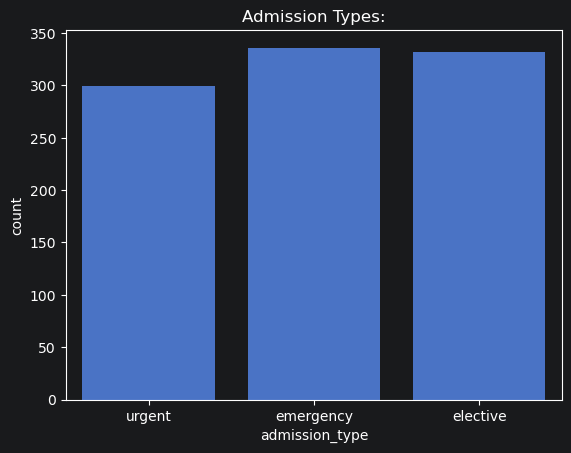

In [40]:
# Display readmissions (target).
sns.countplot(data=df_medical, x="admission_type")
plt.title("Admission Types:")
plt.show()

### Age Distribution

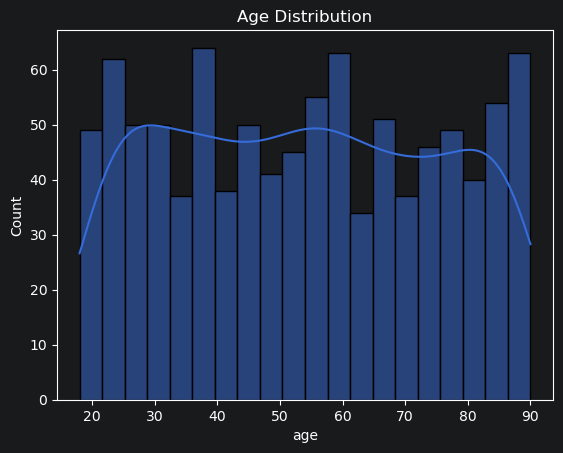

In [41]:
# Plot age histogram.
sns.histplot(df_medical["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

### Chronic Condition Count Distribution

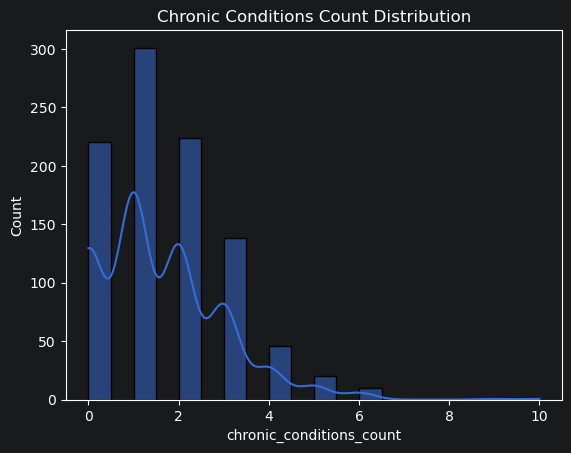

In [42]:
# Plot conditions histogram.
sns.histplot(df_medical["chronic_conditions_count"], bins=20, kde=True)
plt.title("Chronic Conditions Count Distribution")
plt.show()

### Readmission by Chronic Conditions Count

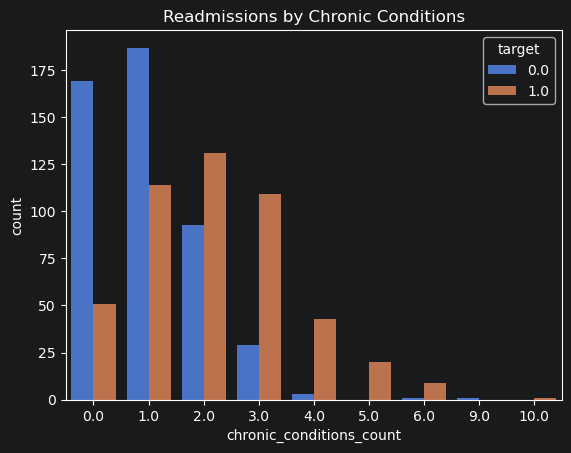

In [43]:
sns.countplot(data=df_medical, x='chronic_conditions_count', hue='target')
plt.title("Readmissions by Chronic Conditions")
plt.show()

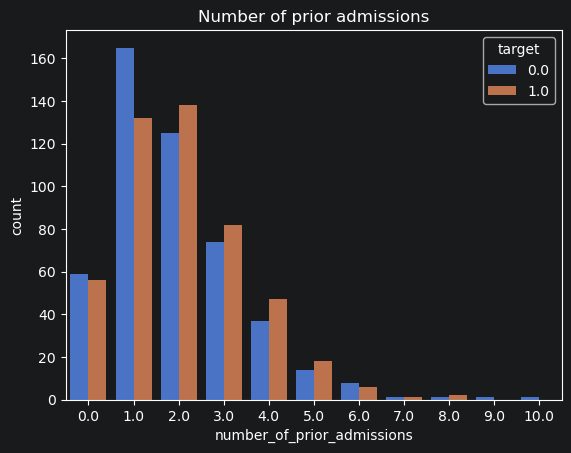

In [44]:
sns.countplot(data=df_medical, x='number_of_prior_admissions', hue='target')
plt.title("Number of prior admissions")
plt.show()

## Preprocessing

### Filling in missing values

In [45]:
# Fill the age value with the median age.
df_medical["age"] = df_medical["age"].fillna(df_medical["age"].median())

# Fill BMI with the mode.
df_medical["bmi"] = df_medical["bmi"].fillna(df_medical["bmi"].mode())

### Encode categories

In [46]:
# One-hot encoding on sex and admission type.
df_medical_enc = pd.get_dummies(df_medical, columns=["sex", "admission_type"])
df_medical_enc.head()

,age,bmi,number_of_prior_admissions,chronic_conditions_count,severity_score,lab_result_severity,vitals_instability_score,treatment_complexity,hospital_load_index,physician_workload,target,sex_F,sex_M,admission_type_elective,admission_type_emergency,admission_type_urgent
0,35.0,31.4,0.0,1.0,66.0,52.8,46.8,38.5,0.61,NaN,1.0,False,True,False,False,True
1,22.0,23.6,4.0,3.0,78.9,77.9,37.1,66.1,0.06,0.37,1.0,True,False,False,False,True
2,43.0,22.2,1.0,1.0,22.6,71.3,52.8,14.9,0.41,0.81,0.0,True,False,False,True,False
3,23.0,26.3,1.0,1.0,28.8,54.2,71.4,22.9,0.92,0.40,1.0,True,False,False,True,False
4,24.0,27.0,2.0,NaN,80.5,60.1,16.7,60.5,0.48,0.48,1.0,False,True,False,False,False


### Features and Target definition

In [47]:
# Define features.
med_X = df_medical_enc.drop("target", axis=1)
# Define target.
med_y = df_medical_enc["target"]

### Train/test split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(med_X, med_y, test_size=0.2, random_state=42)

### Pipeline setup

In [49]:
# Pipeline for preprocessing definition
preprocess_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ]
        )

## Machine Learning Models

### Model 1: Logistic Regression

In [50]:
# Set up the pipeline.
reg_pipe = Pipeline(
    steps=[
        ("preprocessing", preprocess_pipe),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)
# Train the pipeline.
reg_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', LogisticRegression(max_iter=1000))])

### Prediction and scoring.

In [51]:
# Apply predictions
reg_y_predict = reg_pipe.predict(X_test)

# Accuracy readout
reg_accuracy = accuracy_score(y_test, reg_y_predict)
reg_precision = precision_score(y_test, reg_y_predict)
reg_recall = recall_score(y_test, reg_y_predict)

print(f"Accuracy: {reg_accuracy:.4f}")
print(f"Precision: {reg_precision:.4f}")
print(f"Recall: {reg_recall:.4f}")

Accuracy: 0.8333
Precision: 0.8641
Recall: 0.8165


### Logistic Regression Precision/Recall tradeoff

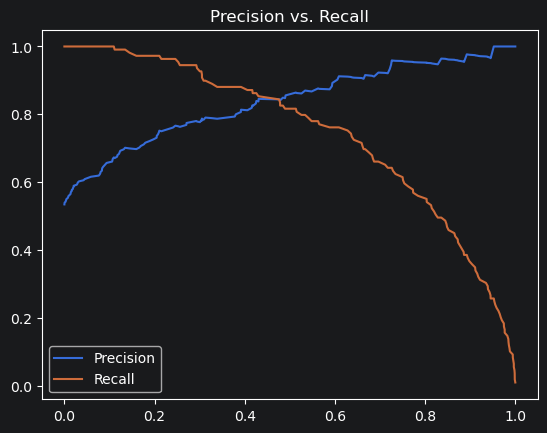

In [52]:
# Get the precision-recall tradeoff of the logistic regression model.
reg_y_prob = reg_pipe.predict_proba(X_test)[:,1]
reg_precision, reg_recall, reg_thresh = precision_recall_curve(y_test, reg_y_prob)

# Plot out the curves.
plt.plot(reg_thresh, reg_precision[:-1], label = "Precision")
plt.plot(reg_thresh, reg_recall[:-1], label = "Recall")
plt.legend()
plt.title("Precision vs. Recall")
plt.show()

### Logistic Regression Confusion Matrix

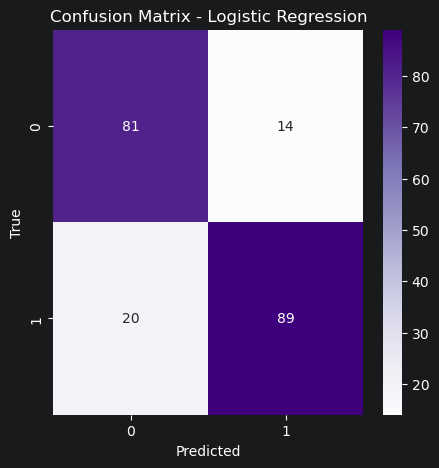

In [53]:
# Create a confusion matrix.
reg_confusion = confusion_matrix(y_test, reg_y_predict)

plt.figure(figsize=[5, 5])
sns.heatmap(reg_confusion, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Model 2: SVC

In [54]:
# Create and fit an SVC.
svc_pipe = Pipeline([
    ("preprocessing", preprocess_pipe),
    ("model", SVC(kernel="linear", random_state=42)),
]
)
svc_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', SVC(kernel='linear', random_state=42))])

### Basic metrics of SVC

In [55]:
# Apply predictions
svc_y_predict = svc_pipe.predict(X_test)

# Accuracy readout
svc_accuracy = accuracy_score(y_test, svc_y_predict)
svc_precision = precision_score(y_test, svc_y_predict)
svc_recall = recall_score(y_test, svc_y_predict)

print(f"Accuracy: {svc_accuracy:.4f}")
print(f"Precision: {svc_precision:.4f}")
print(f"Recall: {svc_recall:.4f}")

Accuracy: 0.8284
Precision: 0.8558
Recall: 0.8165


### Confusion Matrix

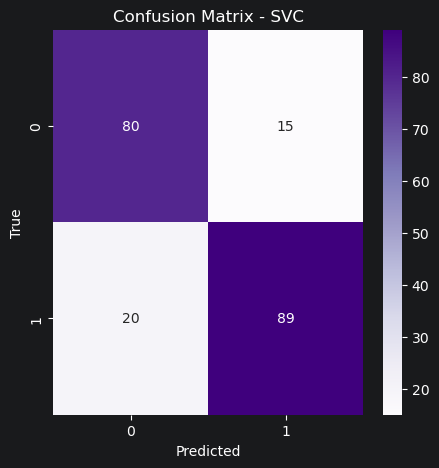

In [56]:
# Create a confusion matrix.
svc_confusion = confusion_matrix(y_test, svc_y_predict)

plt.figure(figsize=[5, 5])
sns.heatmap(svc_confusion, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - SVC")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Model 3: Random Forest

In [57]:
# Set up and fit the pipeline.
forest_pipe = Pipeline([
    ("preprocessing", preprocess_pipe),
    ("model", RandomForestClassifier(n_estimators=101, random_state=42))
])

forest_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model',
                 RandomForestClassifier(n_estimators=101, random_state=42))])

### Basic metrics of Forest

In [58]:
# Apply predictions
forest_y_predict = forest_pipe.predict(X_test)

# Accuracy readout
forest_accuracy = accuracy_score(y_test, forest_y_predict)
forest_precision = precision_score(y_test, forest_y_predict)
forest_recall = recall_score(y_test, forest_y_predict)

print(f"Accuracy: {forest_accuracy:.4f}")
print(f"Precision: {forest_precision:.4f}")
print(f"Recall: {forest_recall:.4f}")

Accuracy: 0.7990
Precision: 0.8469
Recall: 0.7615


### Confusion Matrix

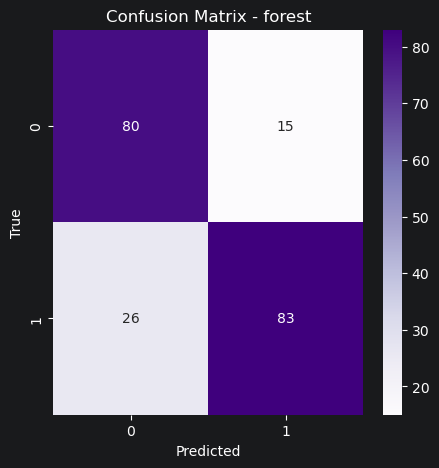

In [59]:
# Create a confusion matrix.
forest_confusion = confusion_matrix(y_test, forest_y_predict)

plt.figure(figsize=[5, 5])
sns.heatmap(forest_confusion, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Model 4: KNN

In [60]:
# Define a pipeline for KNN.
knn_pipe = Pipeline(
    [("imputer", SimpleImputer(strategy="median")),
     ("preprocessing", preprocess_pipe),
     ("model", KNeighborsClassifier(n_neighbors=5))
     ]
)

# Fit the knn pipeline.
knn_pipe.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('preprocessing',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', KNeighborsClassifier())])

### KNN basic metrics

In [61]:
# Apply predictions
knn_y_predict = knn_pipe.predict(X_test)

# Accuracy readout
knn_accuracy = accuracy_score(y_test, knn_y_predict)
knn_precision = precision_score(y_test, knn_y_predict)
knn_recall = recall_score(y_test, knn_y_predict)

print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")

Accuracy: 0.7549
Precision: 0.7980
Recall: 0.7248


### Confusion Matrix

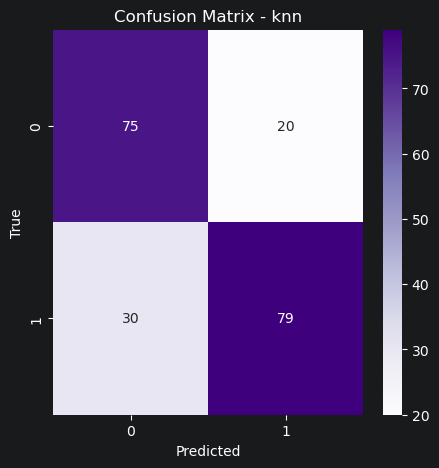

In [62]:
# Create a confusion matrix.
knn_confusion = confusion_matrix(y_test, knn_y_predict)

plt.figure(figsize=[5, 5])
sns.heatmap(knn_confusion, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - knn")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Cross validation of Logistic Regression

In [63]:
reg_scores = cross_val_score(reg_pipe, X_train, y_train, cv=5)
reg_mean = reg_scores.mean()

print(f"Mean score: {reg_mean:.4f}")

Mean score: 0.8162


### Cross-validation of SVC

In [64]:
svc_scores = cross_val_score(svc_pipe, X_train, y_train, cv=5)
svc_cv_mean = svc_scores.mean()

print(f"Cross Validation Mean Score: {svc_cv_mean:.4f}")

Cross Validation Mean Score: 0.8064


### Grid Search of SVC model

In [65]:
### Hyperparameters to test
param_grid = {
    "model__kernel": ["linear", "poly", "rbf", "sigmoid"],
    "model__C": [1, 10, 100]
}

# Create and fit the grid search object.
svc_grid_search = GridSearchCV(svc_pipe, param_grid=param_grid, cv=5)
svc_grid_search.fit(X_train, y_train)

# Print the results.
print(f"Best parameters: {svc_grid_search.best_params_}")
print(f"Best score: {svc_grid_search.best_score_}")

Best parameters: {'model__C': 1, 'model__kernel': 'linear'}
Best score: 0.8064043094418676


## Evaluate Models

## Final Results

In [66]:
accuracy = svc_accuracy
cv_mean = svc_cv_mean
grid_search = svc_grid_search

## Summarize Findings

## FINAL GRADER OUTPUT (*GRADER CONTRACT*)

In [67]:
RESULTS = {
    "accuracy": float(accuracy),  # TODO: replace with accuracy variable from base model if not called 'accuracy'
    "cv_mean": float(cv_mean),  # TODO: replace with cv_mean variable from cross-validation if not called 'cv_mean'
    "best_score": float(grid_search.best_score_)  # TODO: replace with best score variable from cross-validation if not called 'best_score'
}

print("ML Classification Project Completed")
print("-" * 45)
for key, value in RESULTS.items():
    print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")


ML Classification Project Completed
---------------------------------------------
accuracy: 0.8284
cv_mean: 0.8064
best_score: 0.8064


In [68]:
# This is a contract for the grading script.
# Failure to hardcode metrics or change metric names will result in incorrect scoring.

GRADER = {
    "task": "classification",
    "metrics": {
        "accuracy": 0.8284,  # TODO: replace with actual accuracy output from the above cell
        "cv_mean": 0.8064,  # TODO: replace with actual cv_mean output from the above cell
        "best_score": 0.8064  # TODO: replace with actual best_score output from the above cell
    }
}
